# IMports

In [11]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

print("TensorFlow :", tf.__version__)
print("GPU Available :", len(tf.config.list_physical_devices("GPU")))

TensorFlow : 2.21.0
GPU Available : 0


## Path Configuration

In [12]:
TRAIN_DIR = "../classification/train"
VALID_DIR = "../classification/val"
TEST_DIR = "../classification/test"

IMAGE_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-4
MODEL_DIR = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)

# data augmentation

In [13]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.25,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8,1.2),
    fill_mode="nearest"
)
valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

## Dataset load

In [14]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

valid_generator = valid_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
print(train_generator.class_indices)

Found 1820 images belonging to 26 classes.
Found 390 images belonging to 26 classes.
Found 390 images belonging to 26 classes.
{'airplane': 0, 'bed': 1, 'bench': 2, 'bicycle': 3, 'bird': 4, 'bottle': 5, 'bowl': 6, 'bus': 7, 'cake': 8, 'car': 9, 'cat': 10, 'chair': 11, 'couch': 12, 'cow': 13, 'cup': 14, 'dog': 15, 'elephant': 16, 'horse': 17, 'motorcycle': 18, 'person': 19, 'pizza': 20, 'potted plant': 21, 'stop sign': 22, 'traffic light': 23, 'train': 24, 'truck': 25}


## Class Weights

In [15]:
labels = train_generator.classes

class_weights = compute_class_weight(

    class_weight="balanced",

    classes=np.unique(labels),

    y=labels

)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0), 6: np.float64(1.0), 7: np.float64(1.0), 8: np.float64(1.0), 9: np.float64(1.0), 10: np.float64(1.0), 11: np.float64(1.0), 12: np.float64(1.0), 13: np.float64(1.0), 14: np.float64(1.0), 15: np.float64(1.0), 16: np.float64(1.0), 17: np.float64(1.0), 18: np.float64(1.0), 19: np.float64(1.0), 20: np.float64(1.0), 21: np.float64(1.0), 22: np.float64(1.0), 23: np.float64(1.0), 24: np.float64(1.0), 25: np.float64(1.0)}


## Load EfficientNetB0

In [16]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False
print("EfficientNetB0 Loaded Successfully")

EfficientNetB0 Loaded Successfully


# Classification Head

In [17]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(
    1024,
    activation="relu",
    kernel_initializer="he_normal"
)(x)

x = Dropout(0.5)(x)

x = Dense(
    512,
    activation="relu",
    kernel_initializer="he_normal"
)(x)

x = BatchNormalization()(x)

x = Dropout(0.4)(x)

x = Dense(
    256,
    activation="relu",
    kernel_initializer="he_normal"
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

## Compile

In [18]:
model.compile(
    optimizer=Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),
    metrics=["accuracy"]
)

## Callbacks

In [19]:
checkpoint = ModelCheckpoint(
    os.path.join(
        MODEL_DIR,
        "efficientnetb0_best.keras"
    ),

    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1

)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks = [
    checkpoint,
    early_stop,
    reduce_lr
]

## Train Stage-1

In [20]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0356 - loss: 4.7665
Epoch 1: val_accuracy improved from None to 0.06154, saving model to ../models\efficientnetb0_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.0451 - loss: 4.6509 - val_accuracy: 0.0615 - val_loss: 3.2224 - learning_rate: 1.0000e-04
Epoch 2/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - accuracy: 0.0600 - loss: 4.2538
Epoch 2: val_accuracy improved from 0.06154 to 0.12564, saving model to ../models\efficientnetb0_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 56s 983ms/step - accuracy: 0.0731 - loss: 4.1691 - val_accuracy: 0.1256 - val_loss: 3.1059 - learning_rate: 1.0000e-04
Epoch 3/30
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - accuracy: 0.1267 - loss: 3.8760
Epoch 3: val_accuracy improved from 0.12564 to 0.23846, saving model to ../models\efficientnetb0_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 56s 990ms/step - accuracy: 0.1335 - loss: 3.7655 - val_accuracy: 0.2385 - val_loss: 2.9441 - learning_rate: 

## Save Stage-1 Model

In [21]:
stage1_model_path = os.path.join(
    MODEL_DIR,
    "efficientnetb0_stage1.keras"
)

model.save(stage1_model_path)
print("Stage-1 model saved successfully!")

Stage-1 model saved successfully!


## Stage-1 Training Curves

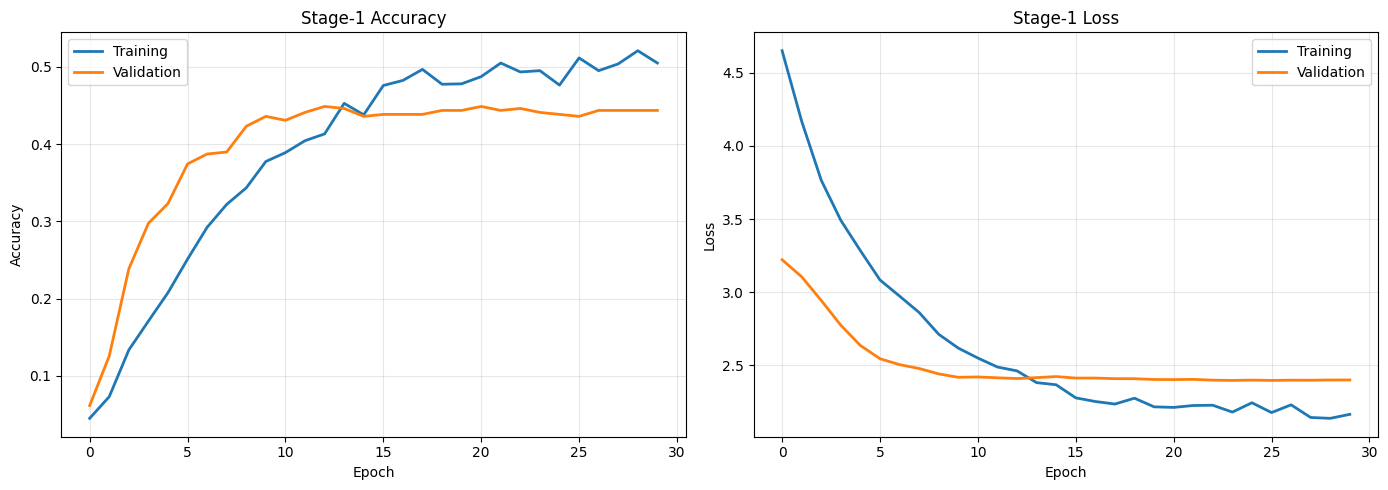

In [22]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(
    history.history["accuracy"],
    linewidth=2,
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    linewidth=2,
    label="Validation"
)

plt.title("Stage-1 Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(alpha=0.3)

plt.subplot(1,2,2)

plt.plot(
    history.history["loss"],
    linewidth=2,
    label="Training"
)

plt.plot(
    history.history["val_loss"],
    linewidth=2,
    label="Validation"
)

plt.title("Stage-1 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Unfreeze Top Layers

In [23]:
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-40:]:
    layer.trainable = True

print("="*60)
print("Trainable Layers")
print("="*60)

trainable_count = 0

for layer in base_model.layers:
    if layer.trainable:
        trainable_count += 1

    print(f"{layer.name:40} : {layer.trainable}")

print("\nTotal Trainable Layers :", trainable_count)

Trainable Layers
input_layer_1                            : False
rescaling_2                              : False
normalization_1                          : False
rescaling_3                              : False
stem_conv_pad                            : False
stem_conv                                : False
stem_bn                                  : False
stem_activation                          : False
block1a_dwconv                           : False
block1a_bn                               : False
block1a_activation                       : False
block1a_se_squeeze                       : False
block1a_se_reshape                       : False
block1a_se_reduce                        : False
block1a_se_expand                        : False
block1a_se_excite                        : False
block1a_project_conv                     : False
block1a_project_bn                       : False
block2a_expand_conv                      : False
block2a_expand_bn                        : False
blo

## Recompile

In [24]:
model.compile(

    optimizer=Adam(
        learning_rate=1e-5
    ),

    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),

    metrics=["accuracy"]

)

## Fine-Tuning

In [25]:
fine_tune_epochs = 20
history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=fine_tune_epochs,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 952ms/step - accuracy: 0.4098 - loss: 2.5389
Epoch 1: val_accuracy did not improve from 0.44872
57/57 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.3945 - loss: 2.5347 - val_accuracy: 0.4462 - val_loss: 2.4285 - learning_rate: 1.0000e-05
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 957ms/step - accuracy: 0.4149 - loss: 2.4721
Epoch 2: val_accuracy did not improve from 0.44872
57/57 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.4214 - loss: 2.4453 - val_accuracy: 0.4385 - val_loss: 2.4613 - learning_rate: 1.0000e-05
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 937ms/step - accuracy: 0.4267 - loss: 2.4433
Epoch 3: val_accuracy did not improve from 0.44872

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
57/57 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.4148 - loss: 2.4712 - val_accuracy: 0.4410 - val_loss: 2.4801 - learning_rate: 1.0000e-05
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 983ms/step - accuracy: 0.4078 - loss: 2.4

## Save Final Model

In [26]:
final_model_path = os.path.join(
    MODEL_DIR,
    "efficientnetb0_final.keras"
)

model.save(final_model_path)
print("Final model saved successfully!")

Final model saved successfully!


## Evaluate

In [27]:
loss, accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print("="*55)
print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")
print("="*55)

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 585ms/step - accuracy: 0.4077 - loss: 2.3266
Test Accuracy : 40.77%
Test Loss     : 2.3266


## Predictions

In [28]:
test_generator.reset()

predictions = model.predict(
    test_generator,
    verbose=1
)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 698ms/step


## Confusion Matrix

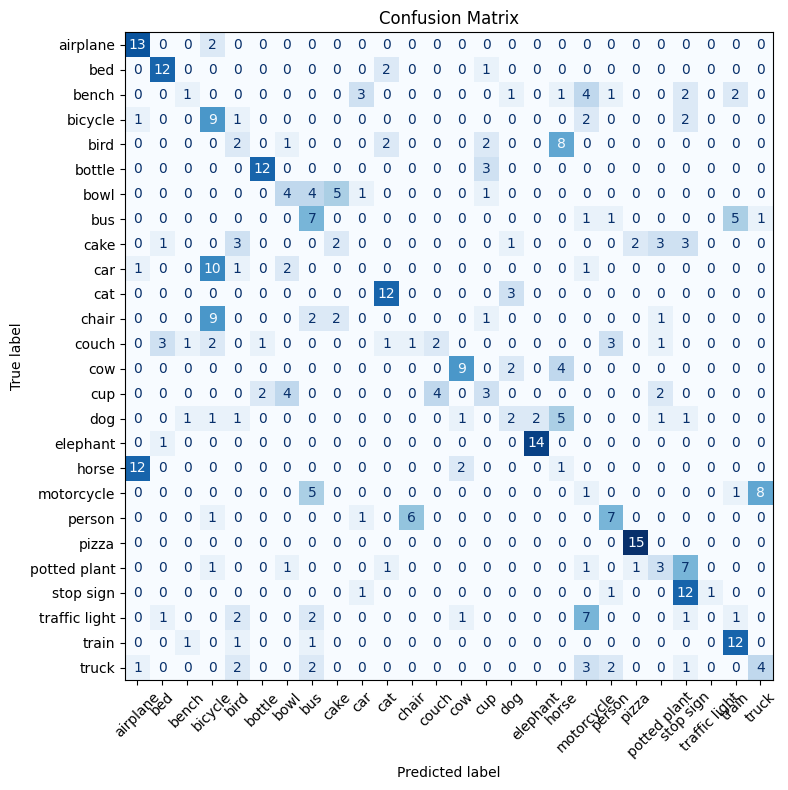

In [29]:
cm = confusion_matrix(
    y_true,
    y_pred
)
fig, ax = plt.subplots(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(
    cmap="Blues",
    ax=ax,
    xticks_rotation=45,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Classification Report

In [30]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

               precision    recall  f1-score   support

     airplane       0.46      0.87      0.60        15
          bed       0.67      0.80      0.73        15
        bench       0.25      0.07      0.11        15
      bicycle       0.26      0.60      0.36        15
         bird       0.15      0.13      0.14        15
       bottle       0.80      0.80      0.80        15
         bowl       0.33      0.27      0.30        15
          bus       0.30      0.47      0.37        15
         cake       0.22      0.13      0.17        15
          car       0.00      0.00      0.00        15
          cat       0.67      0.80      0.73        15
        chair       0.00      0.00      0.00        15
        couch       0.33      0.13      0.19        15
          cow       0.69      0.60      0.64        15
          cup       0.27      0.20      0.23        15
          dog       0.22      0.13      0.17        15
     elephant       0.88      0.93      0.90        15
        h

## Fine-Tuning Curves

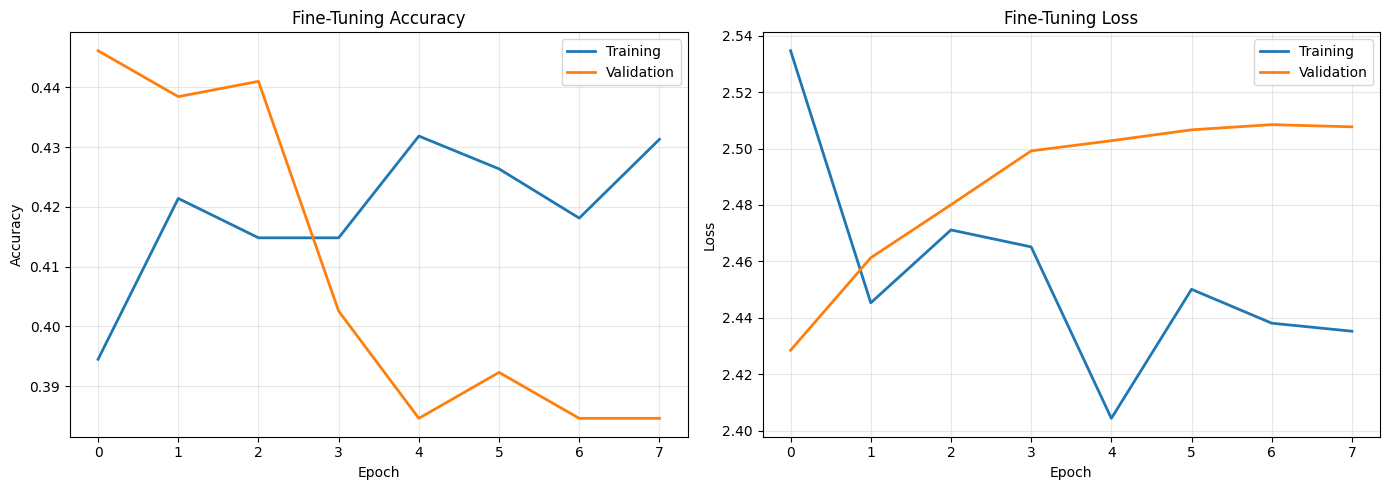

In [31]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(
    history_fine.history["accuracy"],
    linewidth=2,
    label="Training"
)

plt.plot(
    history_fine.history["val_accuracy"],
    linewidth=2,
    label="Validation"
)

plt.title("Fine-Tuning Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(alpha=0.3)

plt.subplot(1,2,2)

plt.plot(
    history_fine.history["loss"],
    linewidth=2,
    label="Training"
)

plt.plot(
    history_fine.history["val_loss"],
    linewidth=2,
    label="Validation"
)

plt.title("Fine-Tuning Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Training Summary

In [32]:
print("="*70)
print("SmartVision V2 - EfficientNetB0 Training Complete")
print("="*70)

print(f"Number of Classes : {NUM_CLASSES}")
print(f"Image Size        : {IMAGE_SIZE}")
print(f"Batch Size        : {BATCH_SIZE}")

print(f"\nFinal Test Accuracy : {accuracy*100:.2f}%")
print(f"Final Test Loss     : {loss:.4f}")

print("\nSaved Models")

print(f"Best Model   : {os.path.join(MODEL_DIR,'efficientnetb0_best.keras')}")
print(f"Stage-1 Model: {os.path.join(MODEL_DIR,'efficientnetb0_stage1.keras')}")
print(f"Final Model  : {os.path.join(MODEL_DIR,'efficientnetb0_final.keras')}")

print("="*70)

SmartVision V2 - EfficientNetB0 Training Complete
Number of Classes : 26
Image Size        : (224, 224)
Batch Size        : 32

Final Test Accuracy : 40.77%
Final Test Loss     : 2.3266

Saved Models
Best Model   : ../models\efficientnetb0_best.keras
Stage-1 Model: ../models\efficientnetb0_stage1.keras
Final Model  : ../models\efficientnetb0_final.keras
